In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2019_ICM_E/tools/')
from PPPM_primitive_data import PPPM_primitive_datasets
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
plastic_processing_data = PPPM_primitive_datasets(1000)

In [3]:
batch_size = 5
data_loader = LoadArray(plastic_processing_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(

    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'sgd',{'learning_rate':0.000001})

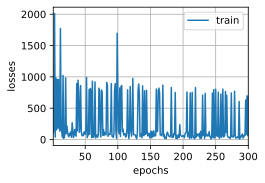

In [6]:
epochs = 300
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,300])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))
        
                

In [7]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[23.13,21.22,511,16.91]])
model(feature)

array([[106.81436]])